In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Tokenization

### Model

In [39]:
# dataset = [
#     ("The quick brown fox jumps over the lazy dog", "DET ADJ ADJ NOUN VERB ADP DET ADJ NOUN"),
#     ("A small cat sleeps peacefully", "DET ADJ NOUN VERB ADV"),
#     ("She gracefully danced in the rain", "PRON ADV VERB ADP DET NOUN"),
#     ("They happily celebrated their victory", "PRON ADV VERB DET NOUN"),
#     ("He quietly reads his favorite book", "PRON ADV VERB DET ADJ NOUN"),
#     ("We will visit the beautiful park tomorrow", "PRON VERB VERB DET ADJ NOUN ADV"),
#     ("You should always respect your elders", "PRON VERB ADV VERB DET NOUN"),
#     ("I absolutely love playing video games", "PRON ADV VERB VERB ADJ NOUN"),
#     ("The tall green tree swayed gently", "DET ADJ ADJ NOUN VERB ADV"),
#     ("Some playful puppies chased a red ball", "DET ADJ NOUN VERB DET ADJ NOUN"),
#     ("The old house stood silently", "DET ADJ NOUN VERB ADV"),
#     ("A bright star twinkled in the night sky", "DET ADJ NOUN VERB ADP DET ADJ NOUN"),
#     ("He carefully opened the mysterious box", "PRON ADV VERB DET ADJ NOUN"),
#     ("They eagerly awaited the delicious meal", "PRON ADV VERB DET ADJ NOUN"),
#     ("She quickly finished her homework", "PRON ADV VERB DET NOUN"),
#     ("We often go to the crowded market", "PRON ADV VERB ADP DET ADJ NOUN"),
#     ("You must listen to the wise advice", "PRON VERB VERB ADP DET ADJ NOUN"),
#     ("I enjoy watching the colorful sunset", "PRON VERB VERB DET ADJ NOUN"),
#     ("The heavy rain poured down", "DET ADJ NOUN VERB ADV"),
#     ("Some curious children explored the ancient cave", "DET ADJ NOUN VERB DET ADJ NOUN"),
#     ("The gentle breeze whispered through the trees", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("A loud siren echoed in the distance", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("He slowly walked along the sandy beach", "PRON ADV VERB ADP DET ADJ NOUN"),
#     ("They bravely faced the dangerous challenge", "PRON ADV VERB DET ADJ NOUN"),
#     ("She excitedly unwrapped the surprise gift", "PRON ADV VERB DET ADJ NOUN"),
#     ("We rarely eat at the fancy restaurant", "PRON ADV VERB ADP DET ADJ NOUN"),
#     ("You should always tell the honest truth", "PRON VERB ADV VERB DET ADJ NOUN"),
#     ("I prefer reading the classic novels", "PRON VERB VERB DET ADJ NOUN"),
#     ("The dark clouds gathered overhead", "DET ADJ NOUN VERB ADV"),
#     ("Some wild animals roamed the dense forest", "DET ADJ NOUN VERB DET ADJ NOUN"),
#     ("The sparkling river flowed through the valley", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("A sudden storm erupted in the afternoon", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("He skillfully played the complex melody", "PRON ADV VERB DET ADJ NOUN"),
#     ("They passionately discussed the important issue", "PRON ADV VERB DET ADJ NOUN"),
#     ("She gracefully moved across the stage", "PRON ADV VERB ADP DET NOUN"),
#     ("We seldom travel to the distant islands", "PRON ADV VERB ADP DET ADJ NOUN"),
#     ("You must respect the local customs", "PRON VERB VERB DET ADJ NOUN"),
#     ("I love listening to the soothing music", "PRON VERB VERB ADP DET ADJ NOUN"),
#     ("The bright moon illuminated the night", "DET ADJ NOUN VERB DET NOUN"),
#     ("Some rare flowers bloomed in the garden", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("The silent owl watched from the tree", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("A powerful engine roared down the street", "DET ADJ NOUN VERB ADP DET NOUN"),
#     ("He quickly solved the difficult puzzle", "PRON ADV VERB DET ADJ NOUN"),
#     ("They patiently waited for the delayed train", "PRON ADV VERB ADP DET ADJ NOUN"),
#     ("She gently stroked the soft fur", "PRON ADV VERB DET ADJ NOUN"),
#     ("We usually drink the hot coffee", "PRON ADV VERB DET ADJ NOUN"),
#     ("You should always follow the correct procedure", "PRON VERB ADV VERB DET ADJ NOUN"),
#     ("I enjoy writing the creative stories", "PRON VERB VERB DET ADJ NOUN")
# ]


import json
with open("dataset.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)
    dataset = [d for d in dataset if "{" not in d and "}" not in d]
    
    dataset = dataset[:100]
    
import random
test_Y = random.sample(dataset, 5)
test_X = []
for item in test_Y:
    values = item[0].split(" ")
    namespaces = item[1].split(" ")
    
    test_X.append((
        " ".join(values[:len(values)-3]), 
        " ".join(namespaces[:len(namespaces)-3])
    ))

for i, Y in enumerate(test_Y):
    print(test_X[i])
    print(Y)

('<EOL> Param3 ; <EOL> ) <EOL> [', 'ANY VARPARAM ANY ANY ANY ANY ANY')
['<EOL> Param3 ; <EOL> ) <EOL> [ <EOL> X ;', 'ANY VARPARAM ANY ANY ANY ANY ANY ANY VARPARAM ANY']
('[ <EOL> ] <EOL> Main [ <EOL> Return ( Self ) ; <EOL>', 'ANY ANY ANY ANY STATE ANY ANY FUNC ANY VARPARAM ANY ANY ANY')
['[ <EOL> ] <EOL> Main [ <EOL> Return ( Self ) ; <EOL> ] <EOL> 0', 'ANY ANY ANY ANY STATE ANY ANY FUNC ANY VARPARAM ANY ANY ANY ANY ANY ANY']
('<EOL> Constant PAGEHOSTWIN = ; <EOL>', 'ANY VARPARAM VARPARAM ANY ANY ANY')
['<EOL> Constant PAGEHOSTWIN = ; <EOL> Constant = ;', 'ANY VARPARAM VARPARAM ANY ANY ANY VARPARAM ANY ANY']
('<EOL> Variable3 ( ) ; <EOL> Constant Variable4 ( )', 'ANY FUNC ANY ANY ANY ANY VARPARAM FUNC ANY ANY')
['<EOL> Variable3 ( ) ; <EOL> Constant Variable4 ( ) = <STRING_VAL> ;', 'ANY FUNC ANY ANY ANY ANY VARPARAM FUNC ANY ANY ANY ANY ANY']
('<EOL> Shared Variable2 (', 'ANY VARPARAM FUNC ANY')
['<EOL> Shared Variable2 ( 0 ) ;', 'ANY VARPARAM FUNC ANY ANY ANY ANY']


In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Assuming 'dataset' is defined somewhere with your data
sentences = [r[0] for r in dataset]

# Create vocabulary
words = set()
for sentence in sentences:
    words.update(sentence.split())

word_to_index = {word: i + 1 for i, word in enumerate(words)}  # 0 reserved for padding
index_to_word = {i: word for word, i in word_to_index.items()}
vocab_size = len(word_to_index) + 1  # +1 for padding

# Create input and target sequences
X = []
y = []
for sentence in sentences:
    sequence = [word_to_index[word] for word in sentence.split()]
    for i in range(1, len(sequence)):
        X.append(sequence[:i])
        y.append(sequence[i])

# Pad sequences
max_length = max(len(seq) for seq in X)
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=max_length, padding='pre')

# Convert target to one-hot encoding
y_one_hot = to_categorical(y, num_classes=vocab_size)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

def create_sequence_prediction_model(vocab_size, embedding_dim, lstm_units):
    inputs = Input(shape=(None,))
    embedding = Embedding(vocab_size, embedding_dim)(inputs)
    lstm = LSTM(lstm_units)(embedding)
    outputs = Dense(vocab_size, activation='softmax')(lstm)
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile the model
embedding_dim = 128
lstm_units = 256
model = create_sequence_prediction_model(vocab_size, embedding_dim, lstm_units)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

def predict_next_words(seed_text, num_words=3, temperature=1.0):
    """
    Predict the next words given a seed text.
    
    Args:
        seed_text (str): The input text to start prediction from
        num_words (int): Number of words to predict (default: 3)
        temperature (float): Controls randomness in predictions (higher = more random)
    
    Returns:
        str: The seed text followed by predicted words
    """
    current_text = seed_text
    for _ in range(num_words):
        # Prepare input sequence
        sequence = [word_to_index.get(word, 0) for word in current_text.split()]
        sequence = tf.keras.preprocessing.sequence.pad_sequences(
            [sequence], maxlen=max_length, padding='pre')
        
        # Get prediction probabilities
        predictions = model.predict(sequence, verbose=0)[0]
        
        # Apply temperature
        predictions = np.log(predictions) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)
        
        # Sample from the distribution
        predicted_index = np.random.choice(range(vocab_size), p=predictions)
        
        # Skip padding token
        if predicted_index == 0:
            continue
            
        predicted_word = index_to_word.get(predicted_index, 'UNK')
        current_text += ' ' + predicted_word
    
    return current_text

for i, Y in enumerate(test_Y):
    print("INPUT:", test_X[i][0])
    print("PREDICTION:", predict_next_words(test_X[i][0]))
    print("EXPECTED:", Y)


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 282ms/step - accuracy: 0.1401 - loss: 3.8179 - val_accuracy: 0.1571 - val_loss: 3.2480
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.1891 - loss: 3.1043 - val_accuracy: 0.3333 - val_loss: 2.8802
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.3841 - loss: 2.5645 - val_accuracy: 0.5057 - val_loss: 2.2796
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.5157 - loss: 2.0107 - val_accuracy: 0.5939 - val_loss: 1.8897
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.5897 - loss: 1.6035 - val_accuracy: 0.6437 - val_loss: 1.5994
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.7001 - loss: 1.3266 - val_accuracy: 0.6705 - val_loss: 1.4498
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.7196 - loss: 1.1358 - val_accuracy: 0.7356 - val_loss: 1.3099
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.7489 - loss: 0.9922 - val_acc

In [41]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Sample dataset with multiple properties
# Format: (text, property1, property2, ...)
def build_vocabularies(dataset):
    """Build vocabularies for words and each property type."""
    word_vocab = set()
    property_vocabs = []  # List of sets, one for each property type
    
    # Initialize property vocabularies
    num_properties = len(dataset[0]) - 1
    property_vocabs = [set() for _ in range(num_properties)]
    
    for item in dataset:
        words = item[0].split()
        word_vocab.update(words)
        
        for prop_idx in range(num_properties):
            properties = item[prop_idx+1].split()
            property_vocabs[prop_idx].update(properties)
    
    return word_vocab, property_vocabs

word_vocab, property_vocabs = build_vocabularies(dataset)

# Create mappings for words and each property type
word_to_idx = {word: i+1 for i, word in enumerate(word_vocab)}  # 0 for padding
idx_to_word = {i: word for word, i in word_to_idx.items()}

property_to_idx = []
idx_to_property = []
for vocab in property_vocabs:
    prop_map = {prop: i+1 for i, prop in enumerate(vocab)}
    idx_prop = {i: prop for prop, i in prop_map.items()}
    property_to_idx.append(prop_map)
    idx_to_property.append(idx_prop)

word_vocab_size = len(word_to_idx) + 1
property_vocab_sizes = [len(p) + 1 for p in property_to_idx]

def prepare_sequences(dataset):
    """Prepare training sequences with words and all properties."""
    X_words = []
    X_properties = [[] for _ in range(len(property_vocabs))]  # List of lists for each property
    y_word = []
    y_properties = [[] for _ in range(len(property_vocabs))]
    
    for item in dataset:
        words = item[0].split()
        word_ids = [word_to_idx[word] for word in words]
        
        # Get all property sequences
        prop_sequences = []
        for prop_idx in range(len(property_vocabs)):
            # Check if we have enough properties for this item
            if prop_idx + 1 >= len(item):
                raise ValueError(f"Item missing property {prop_idx + 1}: {item}")
                
            props = item[prop_idx + 1].split()
            # Verify property sequence length matches word sequence length
            if len(props) != len(words):
                raise ValueError(
                    f"Property {prop_idx + 1} length ({len(props)}) doesn't match word length ({len(words)}) in: {item}"
                )
                
            prop_ids = [property_to_idx[prop_idx][prop] for prop in props]
            prop_sequences.append(prop_ids)
        
        # Create training sequences
        for i in range(1, len(words)):
            X_words.append(word_ids[:i])
            for prop_idx in range(len(property_vocabs)):
                X_properties[prop_idx].append(prop_sequences[prop_idx][:i])
            
            y_word.append(word_ids[i])
            for prop_idx in range(len(property_vocabs)):
                y_properties[prop_idx].append(prop_sequences[prop_idx][i])
    
    return X_words, X_properties, y_word, y_properties

X_words, X_properties, y_word, y_properties = prepare_sequences(dataset)

# Pad sequences
max_sequence_length = max(len(seq) for seq in X_words)
X_words_padded = tf.keras.preprocessing.sequence.pad_sequences(X_words, maxlen=max_sequence_length, padding='pre')

X_properties_padded = []
for props in X_properties:
    padded = tf.keras.preprocessing.sequence.pad_sequences(props, maxlen=max_sequence_length, padding='pre')
    X_properties_padded.append(padded)

# Convert targets to one-hot
y_word_onehot = to_categorical(y_word, num_classes=word_vocab_size)
y_properties_onehot = []
for props, vocab_size in zip(y_properties, property_vocab_sizes):
    onehot = to_categorical(props, num_classes=vocab_size)
    y_properties_onehot.append(onehot)

# Split data
split_data = train_test_split(X_words_padded, *X_properties_padded, y_word_onehot, *y_properties_onehot, 
                             test_size=0.2, random_state=42)

X_train_words = split_data[0]
X_test_words = split_data[1]

X_train_props = []
X_test_props = []
for i in range(len(property_vocabs)):
    X_train_props.append(split_data[2 + i*2])
    X_test_props.append(split_data[3 + i*2])

y_train_word = split_data[2 + len(property_vocabs)*2]
y_test_word = split_data[3 + len(property_vocabs)*2]

y_train_props = []
y_test_props = []
offset = 4 + len(property_vocabs)*2
for i in range(len(property_vocabs)):
    y_train_props.append(split_data[offset + i*2])
    y_test_props.append(split_data[offset + 1 + i*2])

def create_multi_property_model(word_vocab_size, property_vocab_sizes, 
                              word_embed_dim=64, prop_embed_dims=32, lstm_units=128):
    """Create a model that handles multiple properties."""
    if isinstance(prop_embed_dims, int):
        prop_embed_dims = [prop_embed_dims] * len(property_vocab_sizes)
    
    # Word input
    word_input = Input(shape=(None,), name='word_input')
    word_embed = Embedding(word_vocab_size, word_embed_dim, name='word_embedding')(word_input)
    
    # Property inputs
    prop_inputs = []
    prop_embeds = []
    for i, (vocab_size, embed_dim) in enumerate(zip(property_vocab_sizes, prop_embed_dims)):
        prop_input = Input(shape=(None,), name=f'property_{i}_input')
        prop_embed = Embedding(vocab_size, embed_dim, name=f'property_{i}_embedding')(prop_input)
        prop_inputs.append(prop_input)
        prop_embeds.append(prop_embed)
    
    # Combine all embeddings
    combined = Concatenate()([word_embed] + prop_embeds)
    
    # LSTM layer
    lstm_out = LSTM(lstm_units)(combined)
    
    # Outputs: word + each property
    outputs = []
    word_output = Dense(word_vocab_size, activation='softmax', name='word_output')(lstm_out)
    outputs.append(word_output)
    
    for i, vocab_size in enumerate(property_vocab_sizes):
        prop_output = Dense(vocab_size, activation='softmax', name=f'property_{i}_output')(lstm_out)
        outputs.append(prop_output)
    
    model = Model(inputs=[word_input] + prop_inputs, outputs=outputs)
    return model

# Create model
prop_embed_dims = [32, 16, 16]  # Can customize embedding size for each property
model = create_multi_property_model(word_vocab_size, property_vocab_sizes, 
                                   prop_embed_dims=prop_embed_dims)

# Compile model
losses = {'word_output': 'categorical_crossentropy'}
metrics = {'word_output': 'accuracy'}
for i in range(len(property_vocab_sizes)):
    losses[f'property_{i}_output'] = 'categorical_crossentropy'
    metrics[f'property_{i}_output'] = 'accuracy'

model.compile(optimizer='adam', loss=losses, metrics=metrics)

# Prepare training data
train_input = {'word_input': X_train_words}
test_input = {'word_input': X_test_words}

for i in range(len(X_train_props)):
    train_input[f'property_{i}_input'] = X_train_props[i]
    test_input[f'property_{i}_input'] = X_test_props[i]

train_output = {'word_output': y_train_word}
test_output = {'word_output': y_test_word}

for i in range(len(y_train_props)):
    train_output[f'property_{i}_output'] = y_train_props[i]
    test_output[f'property_{i}_output'] = y_test_props[i]

# Train the model
history = model.fit(
    train_input,
    train_output,
    epochs=50,
    batch_size=32,
    validation_data=(test_input, test_output))

def predict_sequence(seed_text, seed_properties=None, num_predictions=3, temperature=1.0):
    """Predict sequence with multiple properties."""
    current_words = seed_text.split()
    
    # Initialize properties if not provided
    if seed_properties is None:
        current_properties = [['UNK'] * len(current_words) for _ in range(len(property_vocabs))]
    else:
        current_properties = [props.split() for props in seed_properties]
        if len(current_properties) != len(property_vocabs):
            raise ValueError(f"Expected {len(property_vocabs)} property sequences, got {len(current_properties)}")
    
    for _ in range(num_predictions):
        # Prepare inputs
        word_seq = [word_to_idx.get(word, 0) for word in current_words]
        word_seq = tf.keras.preprocessing.sequence.pad_sequences(
            [word_seq], maxlen=max_sequence_length, padding='pre')
        
        prop_seqs = []
        for prop_idx in range(len(property_vocabs)):
            prop_seq = [property_to_idx[prop_idx].get(prop, 0) for prop in current_properties[prop_idx]]
            prop_seq = tf.keras.preprocessing.sequence.pad_sequences(
                [prop_seq], maxlen=max_sequence_length, padding='pre')
            prop_seqs.append(prop_seq)
        
        # Prepare model inputs
        model_input = {'word_input': word_seq}
        for i in range(len(prop_seqs)):
            model_input[f'property_{i}_input'] = prop_seqs[i]
        
        # Get predictions
        predictions = model.predict(model_input, verbose=0)
        
        # Process word prediction with temperature
        word_probs = np.log(predictions[0][0]) / temperature
        word_probs = np.exp(word_probs) / np.sum(np.exp(word_probs))
        next_word_idx = np.random.choice(range(word_vocab_size), p=word_probs)
        
        if next_word_idx == 0:  # Skip padding
            continue
            
        next_word = idx_to_word.get(next_word_idx, 'UNK')
        current_words.append(next_word)
        
        # Process property predictions
        for prop_idx in range(len(property_vocabs)):
            next_prop_idx = np.argmax(predictions[prop_idx+1][0])
            next_prop = idx_to_property[prop_idx].get(next_prop_idx, 'UNK')
            current_properties[prop_idx].append(next_prop)
    
    # Prepare output
    predicted_text = ' '.join(current_words)
    predicted_properties = [' '.join(props) for props in current_properties]
    
    return predicted_text, predicted_properties

# # Example usage
# for input_text, input_pos in [
#     ("The quick brown fox", "DET ADJ ADJ NOUN"),  # Single string of space-separated POS tags
#     ("She gracefully", "PRON ADV")]:               # Single string of space-separated POS tags
#     predicted_text, predicted_properties = predict_sequence(input_text, [input_pos], num_predictions=3)
#     print(f"\nInput: '{input_text}'")
#     print(f"Input POS: '{input_pos}'")
#     print(f"Predicted text: '{predicted_text}'")
#     print(f"Predicted POS: '{predicted_properties[0]}'")


for i, Y in enumerate(test_Y):    
    input_text = test_X[i][0]
    input_prop = test_X[i][1:]
    print("INPUT:", input_text)
    print("PREDICTION:", predict_sequence(input_text, input_prop, num_predictions=3))
    print("EXPECTED:", Y)

    
    

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 5.1850 - property_0_output_accuracy: 0.6868 - property_0_output_loss: 1.1150 - word_output_accuracy: 0.1005 - word_output_loss: 4.0693 - val_loss: 4.0049 - val_property_0_output_accuracy: 0.7701 - val_property_0_output_loss: 0.6737 - val_word_output_accuracy: 0.0996 - val_word_output_loss: 3.3283
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 3.8544 - property_0_output_accuracy: 0.7815 - property_0_output_loss: 0.6566 - word_output_accuracy: 0.1302 - word_output_loss: 3.1979 - val_loss: 3.8397 - val_property_0_output_accuracy: 0.7701 - val_property_0_output_loss: 0.6273 - val_word_output_accuracy: 0.1801 - val_word_output_loss: 3.2095
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 3.6878 - property_0_output_accuracy: 0.7667 - property_0_output_loss: 0.6247 - word_output_accuracy: 0.2109 - word_output_loss: 3.0628 - val_loss: 3.5642 - val_property_0_output_accuracy: 0.7778 - val_property_0_output_loss: 0.

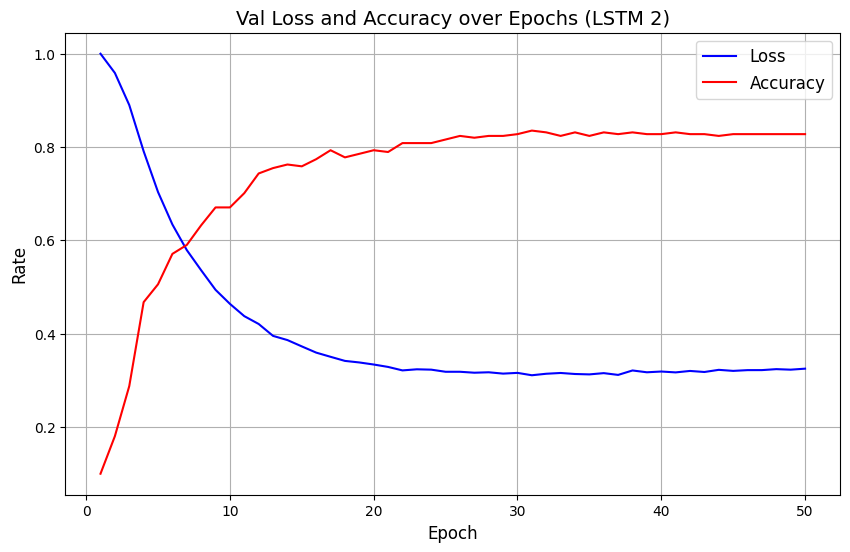

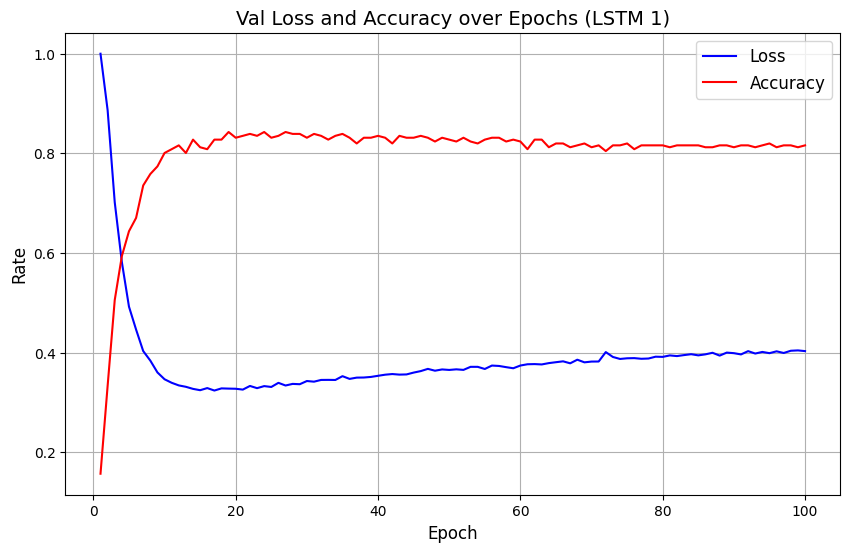

In [58]:
import matplotlib.pyplot as plt

stats = []
with open("result/train-lstm-enhanced.txt", "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
    for line in lines:
        segment = line.split(";")
        data = {}
        for part in segment:
            if part:
                key, value = part.split("=")
                if key == "Epoch": data["Epoch"] = int(value)
                else:
                    try: data[key] = float(value)
                    except: data[key] = value
        if data: stats.append(data)

# Extract data for plotting
epochs = [entry['Epoch'] for entry in stats]
loss = [entry['val_loss'] for entry in stats]
loss = [l/max(loss) for l in loss]
acc = [entry['val_word_output_accuracy'] for entry in stats]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b-', label='Loss')
plt.plot(epochs, acc, 'r-', label='Accuracy')

# Add titles and labels
plt.title('Val Loss and Accuracy over Epochs (LSTM 2)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.show()

stats = []
with open("result/train-lstm.txt", "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
    for line in lines:
        segment = line.split(";")
        data = {}
        for part in segment:
            if part:
                key, value = part.split("=")
                if key == "Epoch": data["Epoch"] = int(value)
                else:
                    try: data[key] = float(value)
                    except: data[key] = value
        if data: stats.append(data)
        

# Extract data for plotting
epochs = [entry['Epoch'] for entry in stats]
loss = [entry['val_loss'] for entry in stats]
loss = [l/max(loss) for l in loss]
acc = [entry['val_accuracy'] for entry in stats]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b-', label='Loss')
plt.plot(epochs, acc, 'r-', label='Accuracy')

# Add titles and labels
plt.title('Val Loss and Accuracy over Epochs (LSTM 1)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Rate', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.show()
